# Energy Price Prediction Pipeline

This notebook implements a modular machine learning pipeline for predicting 24-hour ahead energy price movements using news signals and energy market data.

## Pipeline Stages
1. **Setup & Configuration** - Initialize system and configure compute
2. **Data Ingestion** - Load news and energy data
3. **News Processing** - Extract text features and embeddings
4. **Feature Engineering** - Time-decay aggregation and UMAP
5. **Parameter Optimization** - Grid search over decay parameters
6. **Model Training** - Train XGBoost/LightGBM models
7. **Evaluation** - Performance assessment and statistical testing

## 1. Setup & Imports

This cell loads all the necessary Python tools and modules for the pipeline. It adds the scripts directory to Python's search path so we can access our custom code, imports standard data analysis libraries (pandas, numpy, matplotlib), and loads all our custom modules from the `config/` and `scripts/` directories. The `importlib.reload()` calls ensure we always use the latest version of our code if we've made changes.

In [1]:
# Add scripts directory to path
import sys
from pathlib import Path
import importlib

# Navigate to scripts directory
scripts_dir = Path('../scripts').resolve()
config_dir = Path('../config').resolve()
sys.path.insert(0, str(scripts_dir.parent))

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Custom module imports
from config import pipeline_config as cfg
from config import model_config
from scripts import device_utils
from scripts import profiling
from scripts import data_ingestion
from scripts import feature_engineering as fe
from scripts import model_utils
from scripts import evaluation
from scripts import visualization

# Reload modules to pick up any changes
importlib.reload(device_utils)
importlib.reload(profiling)
importlib.reload(data_ingestion)
importlib.reload(fe)
importlib.reload(model_utils)
importlib.reload(evaluation)
importlib.reload(visualization)

# Configure display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ All modules imported and reloaded successfully")


/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All modules imported and reloaded successfully


## 2. Configure Parameters

**Customize these parameters to tune the pipeline behavior:**

This cell sets all the important settings that control how the pipeline works. Key parameters include:
- **Time windows**: How far back to look for news (LOOKBACK_WINDOW = 336 hours = 2 weeks) and how far ahead to predict (FORECAST_HORIZON = 24 hours)
- **Target definition**: What counts as a significant price movement (SPREAD_DEADBAND = threshold in EUR/MWh)
- **Data splits**: How to divide data into training (70%), validation (20%), and test (10%) sets
- **Feature settings**: Whether to use UMAP (advanced) or PCA (simpler) for reducing embedding dimensions
- **Search settings**: How many parameter combinations to test

All values are loaded from configuration files to keep them organized and easy to change.

In [2]:
# ============================================================================
# CONFIGURABLE PARAMETERS - MODIFY THESE AS NEEDED
# ============================================================================

# Time-series parameters
FORECAST_HORIZON = cfg.FORECAST_HORIZON_HOURS  # 24 hours
LOOKBACK_WINDOW = cfg.DEFAULT_LOOKBACK_WINDOW  # 336 hours (2 weeks)
TIME_DECAY_LAMBDA = cfg.DEFAULT_DECAY_LAMBDA   # 0.05

# Target definition
SPREAD_DEADBAND = cfg.SPREAD_TARGET_DEADBAND   # 5.0 EUR/MWh

# Data splits
TRAIN_RATIO = cfg.TRAIN_RATIO  # 0.7
VAL_RATIO = cfg.VAL_RATIO      # 0.2
TEST_RATIO = cfg.TEST_RATIO    # 0.1

# Feature engineering
USE_UMAP = True  # Use UMAP for dimensionality reduction (False = PCA only)

# Cross-validation
N_CV_SPLITS = cfg.N_CV_SPLITS  # 5
CV_STEP_SIZE = cfg.CV_STEP_SIZE_HOURS  # 24

# Grid search ranges
LOOKBACK_WINDOWS = cfg.LOOKBACK_WINDOWS  # [168, 336, 504]
TIME_DECAY_LAMBDAS = cfg.TIME_DECAY_LAMBDAS  # [0.01, 0.05, 0.1]

# Random search
XGB_RANDOM_SEARCH_ITERS = cfg.XGB_RANDOM_SEARCH_ITERS  # 80 iterations by default

# Data paths (relative to data directory)
NEWS_PATH = "../data/merged_news_v1.csv"
ENERGY_PATH = "../data/energy_data.csv"

print("✓ Configuration loaded")
print(f"  Forecast horizon: {FORECAST_HORIZON} hours")
print(f"  Lookback window: {LOOKBACK_WINDOW} hours")
print(f"  Time decay lambda: {TIME_DECAY_LAMBDA}")
print(f"  Spread deadband: {SPREAD_DEADBAND} EUR/MWh")

✓ Configuration loaded
  Forecast horizon: 24 hours
  Lookback window: 336 hours
  Time decay lambda: 0.05
  Spread deadband: 3.0 EUR/MWh


## 3. Initialize System & Detect Compute Device

This cell automatically detects what computing hardware is available on your machine (CUDA GPU, Apple Silicon GPU, or CPU) and configures optimal settings for that hardware. It determines the best batch size for processing data and sets up the right acceleration method for each task. This ensures the pipeline runs as fast as possible on your specific computer.

In [3]:
# Detect available compute device (GPU/CPU)
device_config = device_utils.detect_compute_device(task='general', verbose=True)

print(f"\n✓ Using device: {device_config['description']}")
print(f"  Optimal batch size: {device_config['optimal_batch_size']}")

✓ MPS detected: Apple Silicon GPU
  Optimal batch size: 128
  XGBoost will fallback to CPU histogram (MPS unsupported)

✓ Using device: Apple MPS GPU
  Optimal batch size: 128


## 4. Stage 1: Data Ingestion

This cell loads and prepares the raw data files. It:
1. **Loads news articles** from CSV with publication timestamps
2. **Loads energy market data** including spot prices, day-ahead auction prices, and power load
3. **Cleans both datasets** by converting timestamps, removing missing values, and filtering by date
4. **Creates the prediction target** by calculating the price spread (difference between spot and auction prices) and classifying it into three categories: Long (+1), Neutral (0), or Short (-1)
5. **Builds historical features** like previous prices/loads from 24 hours and 1 week ago
6. **Adds time-based features** extracted from dates (hour, day of week, month, etc.)

The output is three clean dataframes ready for the next stages: news articles, energy data, and a master dataset combining everything.

In [4]:
with profiling.StageProfiler("Stage 1: Data Ingestion", device_config):
    ingestion_results = data_ingestion.run_ingestion_stage(
        news_path=NEWS_PATH,
        energy_path=ENERGY_PATH,
        min_timestamp=cfg.MIN_TIMESTAMP,
        news_sample=400,  # Set to integer for testing with smaller dataset
        forecast_horizon=FORECAST_HORIZON,
        spread_deadband=SPREAD_DEADBAND,
        random_state=cfg.RANDOM_STATE,
    )

news_df = ingestion_results['news_df']
energy_df = ingestion_results['energy_df']
master_df = ingestion_results['master_df']

print(f"\n✓ Data loaded successfully")
print(f"  News articles: {len(news_df)}")
print(f"  Energy records: {len(energy_df)}")
print(f"  Master records: {len(master_df)}")


[Stage ⏳] Stage 1: Data Ingestion — starting
News shape after filters: (400, 4)
Energy telemetry shape: (7462, 5)
Baseline feature frame: (7270, 16)
[Stage ✅] Stage 1: Data Ingestion — completed in 0.73s
  CPU usage: 31.7% • IO wait: 0.00%
  Disk Δ: +60.9 MB read, +4.7 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Data loaded successfully
  News articles: 400
  Energy records: 7462
  Master records: 7270


### Inspect Data

This cell displays how the prediction targets are distributed across the three classes (Long/Neutral/Short). It shows both the raw counts and percentages, helping you understand if the dataset is balanced or if one class is much more common than others. This is important because imbalanced classes can affect model training.

In [5]:
# Check target distribution
print("Target distribution:")
print(master_df['spread_target_shift_24'].value_counts())
print(f"\nTarget distribution (%)")
print(master_df['spread_target_shift_24'].value_counts(normalize=True) * 100)

Target distribution:
spread_target_shift_24
-1.0    3234
 1.0    3150
 0.0     886
Name: count, dtype: int64

Target distribution (%)
spread_target_shift_24
-1.0    44.484182
 1.0    43.328748
 0.0    12.187070
Name: proportion, dtype: float64


In [6]:
# Check target distribution
print("Target distribution:")
print(master_df['spread_target_shift_24'].value_counts())
print(f"\nTarget distribution (%)")
print(master_df['spread_target_shift_24'].value_counts(normalize=True) * 100)

Target distribution:
spread_target_shift_24
-1.0    3234
 1.0    3150
 0.0     886
Name: count, dtype: int64

Target distribution (%)
spread_target_shift_24
-1.0    44.484182
 1.0    43.328748
 0.0    12.187070
Name: proportion, dtype: float64


## 5. Stage 2A: Zero-Shot Topic Classification

This cell uses an AI model to automatically categorize each news article into energy-related topics without needing labeled training data. It works in two stages:
1. **Stage 1**: Routes each article to a broad category (e.g., "Supply," "Demand," "Fuel Prices")
2. **Stage 2**: Selects the specific topic within that category

Articles classified as "other" (not energy-related) are re-attempted using article descriptions. The result is each article labeled with a topic (e.g., "rising gas prices," "supply disruptions") and a confidence score. This transforms unstructured news text into structured categories the model can use.

In [7]:
with profiling.StageProfiler("Stage 2A: Zero-Shot Topic Classification", device_config):
    classification_results = fe.run_embedding_stage(
        news_df=news_df,
        candidate_labels=cfg.CANDIDATE_LABELS,
        hypothesis_template=cfg.HYPOTHESIS_TEMPLATE,
        device_config=device_config,
        model_name=cfg.ZEROSHOT_MODEL,
        hierarchical_topic_groups=cfg.HIERARCHICAL_TOPIC_GROUPS,
        routing_settings=cfg.HIERARCHICAL_ROUTING_SETTINGS,
    )

news_df = classification_results['news_df']

print(f"\n✓ Classification complete")
print(f"  Unique topics: {news_df['classification'].nunique()}")
print(f"  Articles with classification: {news_df['classification'].notna().sum()}")



[Stage ⏳] Stage 2A: Zero-Shot Topic Classification — starting


Device set to use mps


Processing 400 texts with batch_size=128
Processing 143 texts with batch_size=128
Processing 31 texts with batch_size=128
Processing 15 texts with batch_size=128
Processing 14 texts with batch_size=128
Processing 1 texts with batch_size=128
Processing 196 texts with batch_size=128
Processing 42 texts with batch_size=128
Processing 3 texts with batch_size=128
Processing 8 texts with batch_size=128
Processing 4 texts with batch_size=128
Processing 10 texts with batch_size=128
Processing 5 texts with batch_size=128
Classification completed: 400 articles processed
Articles classified as 'other': 124 (31.0%)

Classification distribution:
classification
kein Bezug zu Energie, Wetter oder Finanzmärkten                                                             124
Regierung, Parlament oder Behörden beschließen strengere Gesetze, Steuern oder Auflagen                      102
Regierung, Parlament oder Behörden lockern Gesetze, Steuern oder Auflagen                                     83
Waffe

In [8]:
# Print at least 50 headlines categorized as "kein Bezug zu Energie, Wetter oder Finanzmärkten"
other_label = cfg.OTHER_LABEL if hasattr(cfg, 'OTHER_LABEL') else "kein Bezug zu Energie, Wetter oder Finanzmärkten"
other_news = news_df[news_df['classification'] == other_label]

print(f"\nSample headlines classified as '{other_label}' (not energy/weather/finance-related):")
with pd.option_context('display.max_colwidth', None):
    print(other_news['title'].head(50).to_string(index=False))



Sample headlines classified as 'kein Bezug zu Energie, Wetter oder Finanzmärkten' (not energy/weather/finance-related):
publishedAt
                                                       Flüssigerdgas: Ostsee-Terminal legt bei LNG-Importen kräftig zu
Serie: „So geht es Deutschland wirklich“ - „Bescheuert“: Warum sich Bäcker Jens Atomkraft und Russen-Gas zurückwünscht
                                                     Banken müssen umstellen - Ab Oktober kommt die Überweisungsampel!
                                              Jetzt noch einsteigen - Diese Aktien starten wegen des Zoll-Kriegs durch
                                                        Sparzinsen im Sinkflug: Tagesgeldzinsen fallen auf 1,4 Prozent
                                      Zollstreit mit den USA: Panter: Firmen müssen Märkte abseits der USA erschließen
                         Unaufgeregtes Verhalten - Gastronom sagt, wie er reiche Kunden in seinem Sterne-Lokal erkennt
                                  

## 6. Stage 2B: Sentence Embeddings

This cell converts news article titles into numerical vectors called "embeddings" - think of them as numeric codes that capture the meaning of the text. It uses a pre-trained language model to transform each title into a 384-dimensional vector where similar articles have similar vectors. The process uses GPU acceleration when available for speed and caches results to avoid recomputing them later. These embeddings allow the machine learning model to understand the semantic content of news.

In [9]:
with profiling.StageProfiler("Stage 2B: Sentence Embeddings", device_config):
    news_df = fe.compute_embeddings(
        news_df=news_df,
        device_config=device_config,
        model_name=cfg.EMBEDDING_MODEL,
        batch_size=device_config['optimal_batch_size'],
        show_progress=True,
        cache_dir=Path('../outputs/.cache/embeddings'),
    )

print(f"\n✓ Embeddings computed")
print(f"  Embedding dimension: {len(news_df.iloc[0]['embedding'])}")


[Stage ⏳] Stage 2B: Sentence Embeddings — starting
Loaded embeddings from cache (../outputs/.cache/embeddings/news_embeddings.parquet)
[Stage ✅] Stage 2B: Sentence Embeddings — completed in 0.08s
  CPU usage: 53.1% • IO wait: 0.00%
  Disk Δ: +13.8 MB read, +0.1 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Embeddings computed
  Embedding dimension: 384


## 7. Plot Comprehensive EDA Dashboard

These cells create visualizations to explore the data. The first generates a comprehensive dashboard showing target distributions, price spreads, news volumes, energy load patterns, and temporal patterns (hourly, daily trends). The second plots the embedding quality using UMAP and t-SNE - two techniques that create 2D scatter plots where similar news articles appear close together. If articles from the same topic cluster together, it means the embeddings are capturing meaningful patterns.

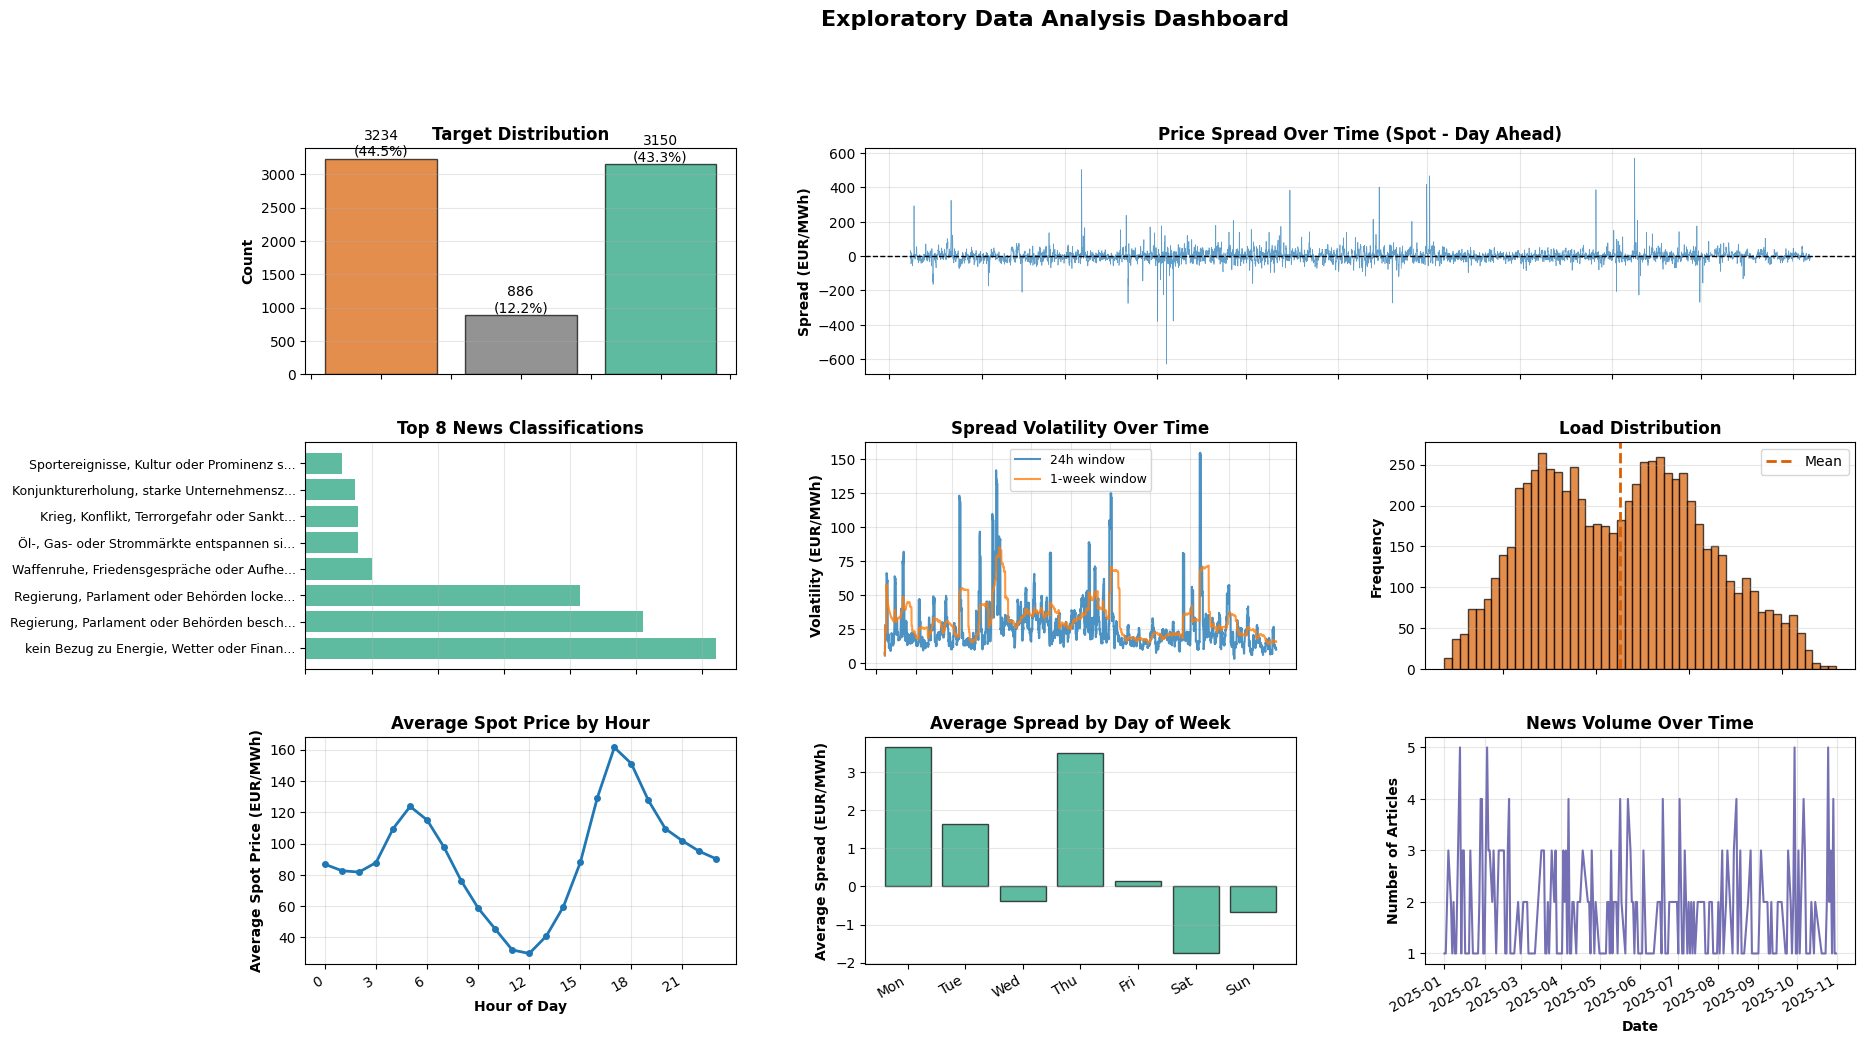

Figure saved: outputs/figures/embedding_quality_umap.png


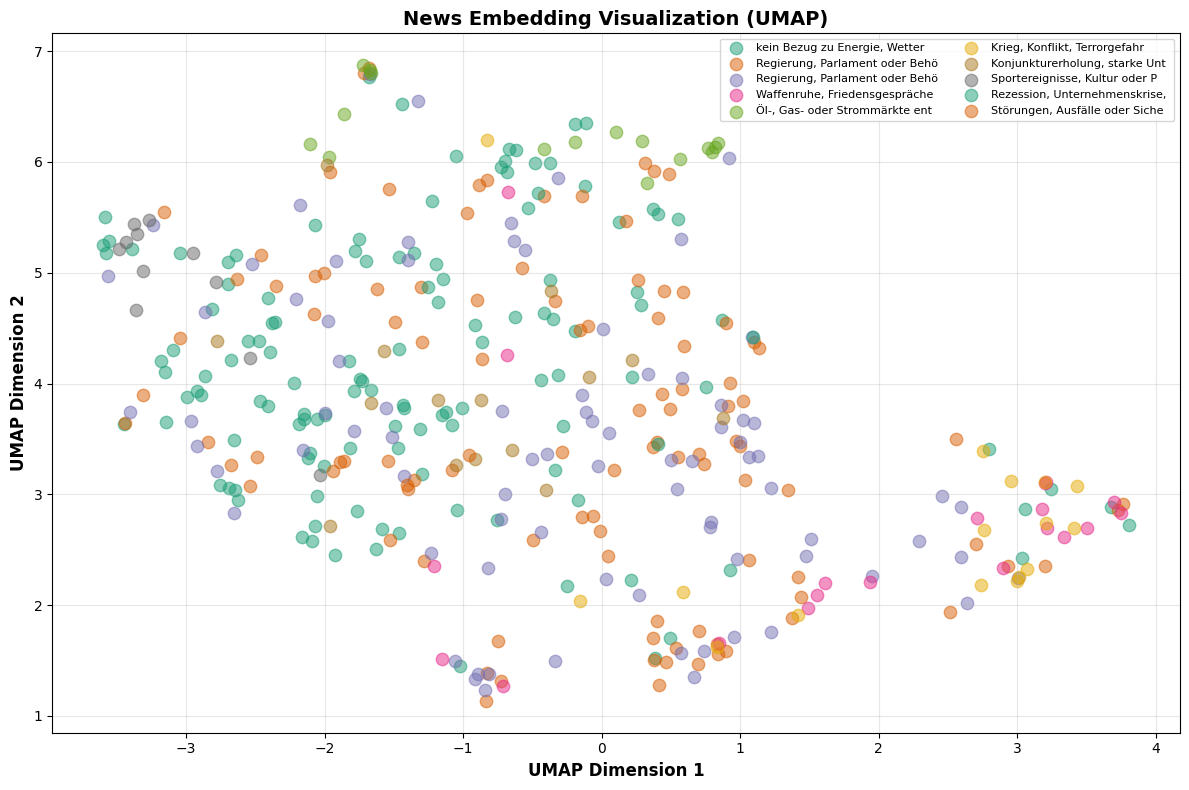

In [10]:
visualization.plot_eda_dashboard(master_df=master_df, news_df=news_df)
visualization.plot_embedding_quality(news_df=news_df, n_samples=500, save_path="embedding_quality_umap")

Generating individual EDA plots for publication...
Figure saved: outputs/figures/top_news_classifications.png


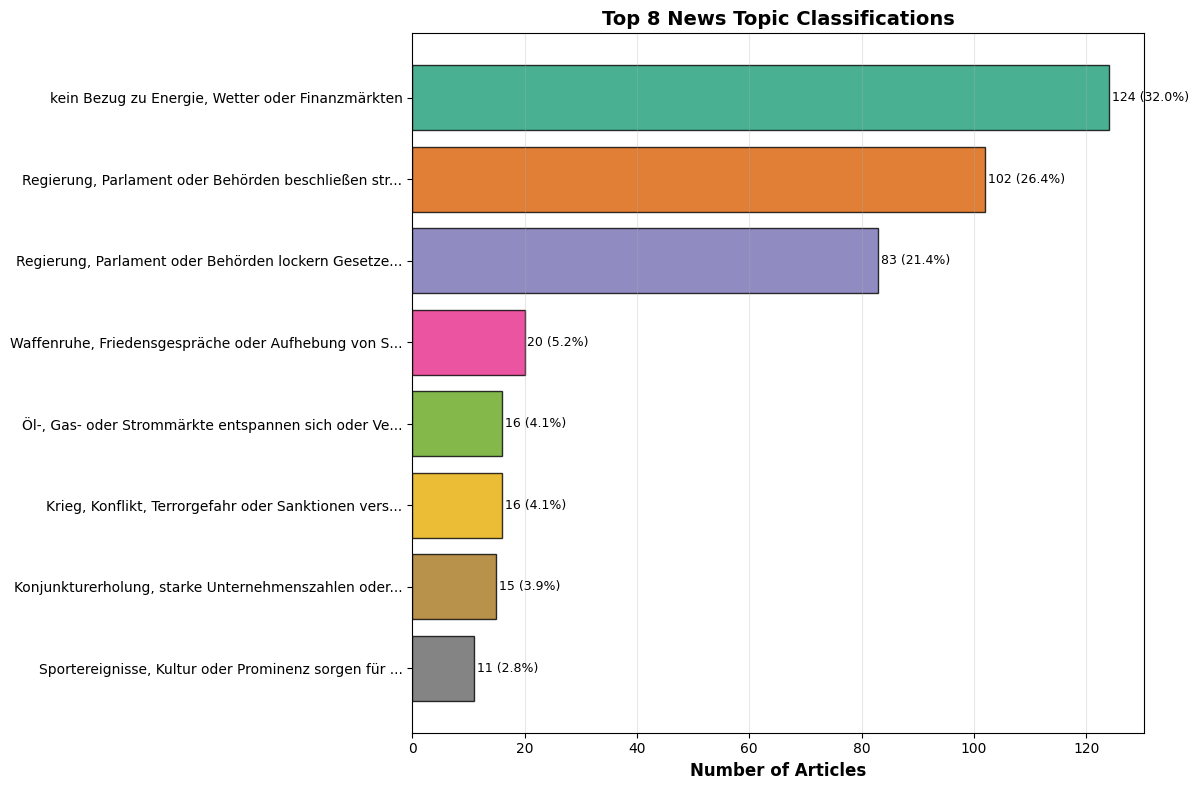

Figure saved: outputs/figures/target_distribution.png


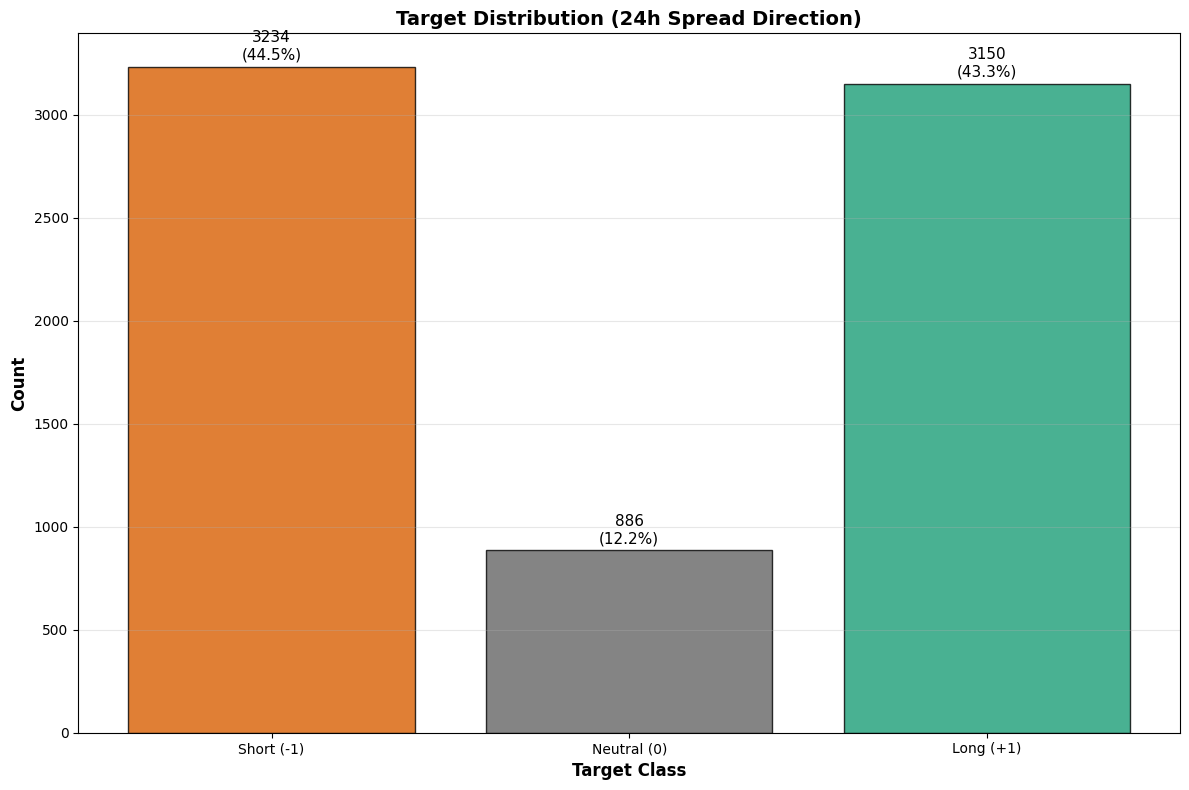

Figure saved: outputs/figures/top_news_sources.png


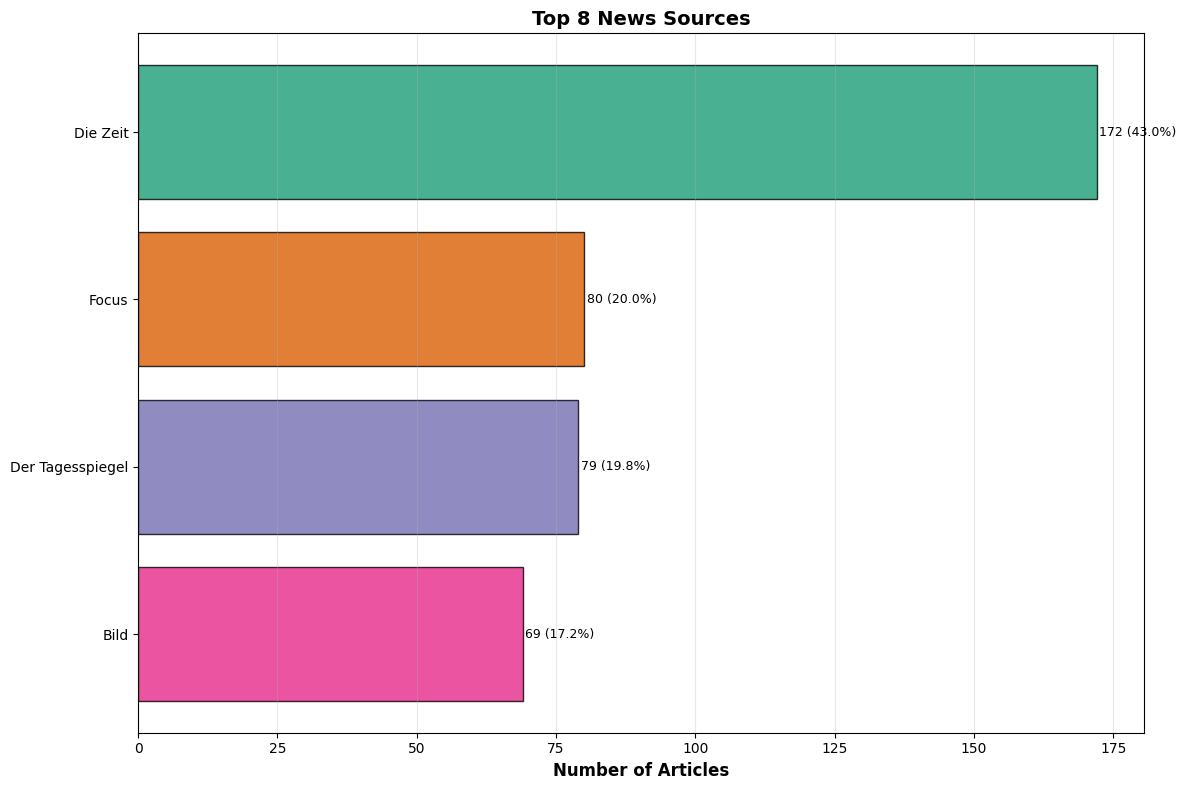

Figure saved: outputs/figures/news_hourly_coverage.png


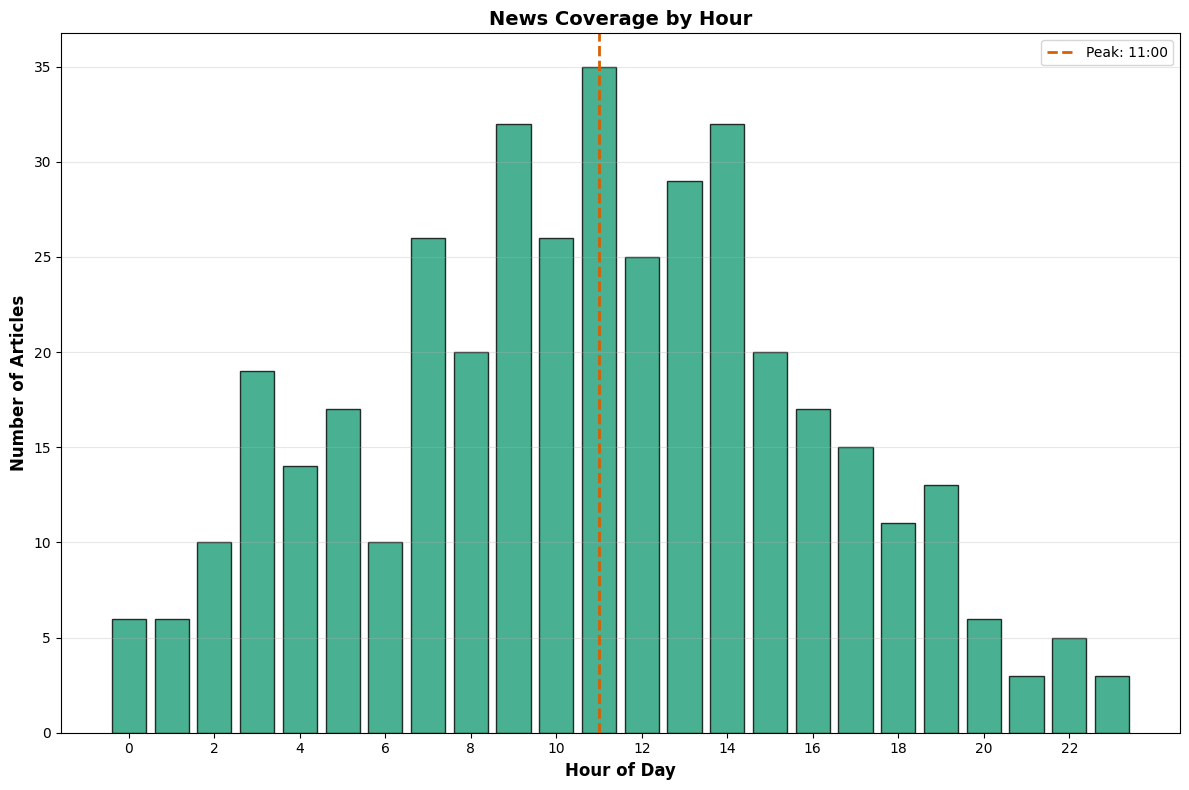


Figures saved to: outputs/figures/


In [11]:
# Individual EDA plots with file export for publication
print("Generating individual EDA plots for publication...")

# Top 8 news classifications
visualization.plot_top_news_classifications(
    news_df=news_df, 
    top_n=8, 
    save_path="top_news_classifications",
    show=True
)

# Target distribution
visualization.plot_target_distribution(
    master_df=master_df,
    target_column=cfg.TARGET_COLUMN,
    save_path="target_distribution",
    show=True
)

# Top 8 news sources
visualization.plot_top_news_sources(
    news_df=news_df,
    top_n=8,
    save_path="top_news_sources", 
    show=True
)

# Hourly news coverage
visualization.plot_news_hourly_coverage(
    news_df=news_df,
    save_path="news_hourly_coverage",
    show=True
)

print(f"\nFigures saved to: {cfg.FIGURES_OUTPUT_DIR}/")

## 8. Stage 3: Feature Engineering - Time-Decay Aggregation

This cell creates time-weighted news features for each timestamp. For every hour in the energy data, it:
1. **Counts relevant news articles** for each topic within the lookback window (e.g., last 2 weeks)
2. **Averages article embeddings** to capture overall news sentiment
3. **Applies time decay**: Recent articles get more weight using the formula `weight = e^(-λ × hours_since)`, so a 1-day-old article counts more than a 1-week-old article
4. **Reduces embedding dimensions** from 384 to 20 using UMAP or PCA to simplify the data
5. **Tests multiple parameter combinations** (different lookback windows and decay rates) in parallel

This creates a library of feature sets with different time-weighting strategies to find which works best for prediction.

In [12]:
with profiling.StageProfiler("Stage 3A: Time-Decay Feature Precomputation", device_config):
    feature_cache = fe.precompute_time_decay_feature_sets(
        news_df=news_df,
        master_df=master_df,
        lookback_windows=LOOKBACK_WINDOWS,
        decay_lambdas=TIME_DECAY_LAMBDAS,
        use_umap=USE_UMAP,
        random_state=cfg.RANDOM_STATE,
        device_config=device_config,
        verbose=True,
    )

print(f"\n✓ Time-decay feature cache built")
print(f"  Parameter combinations: {len(feature_cache)}")
print(f"  Sample keys: {list(feature_cache.keys())[:3]}")


[Stage ⏳] Stage 3A: Time-Decay Feature Precomputation — starting
Precomputing time-decayed features for 30 parameter combinations...
Parallelizing across parameter combinations using joblib (n_jobs=-1)...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw24_dl0.25_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw24_dl0.5_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw48_dl0.01_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw24_dl0.05_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw24_dl0.01_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw48_dl0.05_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw24_dl0.1_reduction.parquet)


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   12.6s


Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw48_dl0.1_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw48_dl0.25_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw48_dl0.5_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw72_dl0.01_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw72_dl0.05_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw72_dl0.25_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw72_dl0.5_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw72_dl0.1_reduction.parquet)


[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   13.2s


Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw168_dl0.01_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw168_dl0.1_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw168_dl0.05_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw168_dl0.5_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw336_dl0.1_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw168_dl0.25_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw336_dl0.01_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw336_dl0.05_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw336_dl0.25_reduction.parquet)


[Parallel(n_jobs=-1)]: Done  19 out of  30 | elapsed:   13.7s remaining:    7.9s
[Parallel(n_jobs=-1)]: Done  23 out of  30 | elapsed:   13.8s remaining:    4.2s


Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw336_dl0.5_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw504_dl0.01_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw504_dl0.05_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw504_dl0.1_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw504_dl0.25_reduction.parquet)
Loaded reduced embeddings from cache (.cache/embeddings/td_embeddings_lw504_dl0.5_reduction.parquet)

✓ Completed precomputation of 30 parameter combinations
[Stage ✅] Stage 3A: Time-Decay Feature Precomputation — completed in 14.16s
  CPU usage: 85.1% • IO wait: 0.00%
  Disk Δ: +593.6 MB read, +1767.8 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Time-decay feature cache built
  Parameter combinations: 30
  Sample keys: [(24, 0.01), (24, 0.05), (24, 0.1)]


[Parallel(n_jobs=-1)]: Done  27 out of  30 | elapsed:   14.1s remaining:    1.6s
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:   14.2s finished


## 9. Stage 3B: Dataset Assembly

This cell combines the time-decay features with the baseline energy data and organizes everything into training, validation, and test sets. For each parameter combination tested earlier, it creates a complete dataset with all features merged together, removes any rows with missing values, and chronologically splits the data (preserving time order) into 70% training, 20% validation, and 10% test. The result is a collection of ready-to-use datasets, one for each parameter combination.

In [13]:
with profiling.StageProfiler("Stage 3B: Dataset Assembly", device_config):
    preprocessed_datasets = fe.assemble_time_decay_datasets(
        master_df=master_df,
        feature_cache=feature_cache,
        target_column=cfg.TARGET_COLUMN,
        train_ratio=cfg.TRAIN_RATIO,
        val_ratio=cfg.VAL_RATIO,
        test_ratio=cfg.TEST_RATIO,
    )

# Select a sample dataset for inspection
sample_params_key = list(preprocessed_datasets.keys())[0]
sample_dataset = preprocessed_datasets[sample_params_key]

print(f"\n✓ Dataset assembly complete")
print(f"  Total datasets: {len(preprocessed_datasets)}")
print(f"  Sample dataset: {sample_dataset['dataset_name']}")
print(f"  Train samples: {len(sample_dataset['train_df'])}")
print(f"  Val samples: {len(sample_dataset['val_df'])}")
print(f"  Test samples: {len(sample_dataset['test_df'])}")
print(f"  News features: {len(sample_dataset['news_features'])}")


[Stage ⏳] Stage 3B: Dataset Assembly — starting


[Stage ✅] Stage 3B: Dataset Assembly — completed in 0.07s
  CPU usage: 0.0% • IO wait: 0.00%
  Disk Δ: +0.5 MB read, +19.5 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Dataset assembly complete
  Total datasets: 30
  Sample dataset: dataset_lw24_dl0.01
  Train samples: 5089
  Val samples: 1454
  Test samples: 727
  News features: 30


## 10. Stage 3C: Dataset Scaling & Summary

This cell normalizes all the news-related features to have the same numerical scale (mean = 0, standard deviation = 1). This is important because some features might naturally have large values (like article counts) while others have small values (like embeddings). Without scaling, features with larger numbers could dominate the model. The scaling is learned from the training data and applied consistently to validation and test sets to avoid "information leakage" from future data.

In [14]:
with profiling.StageProfiler("Stage 3C: Dataset Scaling", device_config):
    preprocessed_datasets = fe.scale_preprocessed_datasets(preprocessed_datasets)

sample_dataset = preprocessed_datasets[sample_params_key]
scaled_news_features = sample_dataset["scaled_news_features"]

print(f"\n✓ Dataset scaling complete")
print(f"  Scaled news features per dataset: {len(scaled_news_features)}")
print(f"  Sample scaled features: {scaled_news_features[:5]}")


[Stage ⏳] Stage 3C: Dataset Scaling — starting
[Stage ✅] Stage 3C: Dataset Scaling — completed in 0.53s
  CPU usage: 0.0% • IO wait: 0.00%
  Disk Δ: +4.0 MB read, +26.2 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Dataset scaling complete
  Scaled news features per dataset: 30
  Sample scaled features: ['Regierung, Parlament oder Behörden beschließen strengere Gesetze, Steuern oder Auflagen_scaled', 'Waffenruhe, Friedensgespräche oder Aufhebung von Sanktionen entspannen die internationale Sicherheitslage_scaled', 'Regierung, Parlament oder Behörden lockern Gesetze, Steuern oder Auflagen_scaled', 'Störungen, Ausfälle oder Sicherheitslücken bei IT/Technologie verursachen Risiken_scaled', 'Öl-, Gas- oder Strommärkte entspannen sich oder Versorgungslage verbessert sich_scaled']


## 11. Stage 3D: Feature Selection with RidgeCV

This cell tests which parameter combination (lookback window and decay rate) produces the best features for prediction. For each combination, it trains a Ridge classifier using expanding-window cross-validation (a time-series-safe method that gradually grows the training set). It measures validation accuracy and F1-score for each combination and ranks them. The top 5 combinations are selected for further testing with more sophisticated models. This step narrows down the massive parameter space to the most promising candidates.

In [15]:
# Define baseline features for XGBoost and upstream stages
baseline_features = [
    "Spot Price", "Day Ahead Auction", "real_spread_abs",
    "price_lag_24", "price_lag_168", "Load", "load_lag_24", "load_lag_168",
    "hour", "day_of_week", "day_of_year", "week_of_year", "month",
]

# Restrict LightGBM baseline inputs to price-only spread signals
lgbm_baseline_features = [
    "real_spread_abs",
    "Day Ahead Auction",
    "Spot Price",
]

# Get news feature definitions from sample dataset
topic_features = sample_dataset["topic_features"]
embedding_features = sample_dataset["embedding_features"]
news_features = sample_dataset["news_features"]
scaled_news_features = sample_dataset["scaled_news_features"]

print(f"✓ Feature sets defined")
print(f"  Baseline: {len(baseline_features)}, Topics: {len(topic_features)}, Embeddings: {len(embedding_features)}, Total news: {len(news_features)}")

# Run Ridge feature selection across parameter combinations
with profiling.StageProfiler("Stage 3D: Ridge Feature Selection", device_config):
    top_5_combinations = fe.grid_search_time_decay_params(
        preprocessed_datasets=preprocessed_datasets,
        baseline_features=baseline_features,
        target_column=cfg.TARGET_COLUMN,
        alphas=cfg.DEFAULT_ALPHAS,
        max_splits=cfg.N_CV_SPLITS,
    )

if top_5_combinations:
    best_params_key = top_5_combinations[0]["params_key"]
    best_dataset = preprocessed_datasets[best_params_key]
    print(f"\n✓ Top parameter combination: {best_dataset['dataset_name']} (lookback={top_5_combinations[0]['lookback_window']}h, lambda={top_5_combinations[0]['decay_lambda']})")
else:
    best_params_key = None
    best_dataset = None
    print("\n⚠ No valid parameter combinations identified. Review grid search configuration.")

✓ Feature sets defined
  Baseline: 13, Topics: 10, Embeddings: 20, Total news: 30

[Stage ⏳] Stage 3D: Ridge Feature Selection — starting
Grid searching 30 parameter combinations...
Using expanding-window RidgeCV confined to training splits (target: spread_target_shift_24)
Parallelizing evaluation across parameter combinations using joblib...



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done  19 out of  30 | elapsed:    1.7s remaining:    1.0s
[Parallel(n_jobs=-1)]: Done  23 out of  30 | elapsed:    1.9s remaining:    0.6s


TOP 5 PARAMETER COMBINATIONS:
1. dataset=dataset_lw504_dl0.5 | lookback=504h | lambda=0.5 | alpha=1000.0000 | Val Accuracy=0.509 | Val Macro-F1=0.367
2. dataset=dataset_lw336_dl0.1 | lookback=336h | lambda=0.1 | alpha=1000.0000 | Val Accuracy=0.500 | Val Macro-F1=0.359
3. dataset=dataset_lw24_dl0.1 | lookback=24h | lambda=0.1 | alpha=3.1623 | Val Accuracy=0.496 | Val Macro-F1=0.356
4. dataset=dataset_lw24_dl0.25 | lookback=24h | lambda=0.25 | alpha=1000.0000 | Val Accuracy=0.495 | Val Macro-F1=0.356
5. dataset=dataset_lw504_dl0.1 | lookback=504h | lambda=0.1 | alpha=1000.0000 | Val Accuracy=0.493 | Val Macro-F1=0.353
[Stage ✅] Stage 3D: Ridge Feature Selection — completed in 2.19s
  CPU usage: 79.4% • IO wait: 0.00%
  Disk Δ: +65.0 MB read, +189.1 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)

✓ Top parameter combination: dataset_lw504_dl0.5 (lookback=504h, lambda=0.5)


[Parallel(n_jobs=-1)]: Done  27 out of  30 | elapsed:    2.1s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:    2.2s finished


## 12. Stage 3E: Summarise Ridge Results

This cell displays a table showing the top 5 parameter combinations found in the previous step. For each combination, it shows the dataset name, lookback window (hours), decay lambda (decay rate), the best Ridge regularization strength (alpha), and validation performance metrics (accuracy and macro F1-score). This lets you quickly compare which settings worked best during preliminary screening.

In [16]:
# Display top 5 Ridge parameter combinations
if top_5_combinations:
    top_5_summary = pd.DataFrame([{
        "dataset_name": res["dataset_name"],
        "lookback_window": res["lookback_window"],
        "decay_lambda": res["decay_lambda"],
        "alpha": res["best_alpha"],
        "val_accuracy": res["val_accuracy"],
        "val_macro_f1": res["val_macro_f1"],
    } for res in top_5_combinations])
    display(top_5_summary)
else:
    print("No RidgeCV results available to summarise.")

,dataset_name,lookback_window,decay_lambda,alpha,val_accuracy,val_macro_f1
0,dataset_lw504_dl0.5,504,0.50,1000.000000,0.508941,0.366649
1,dataset_lw336_dl0.1,336,0.10,1000.000000,0.500000,0.358725
2,dataset_lw24_dl0.1,24,0.10,3.162278,0.495873,0.355748
3,dataset_lw24_dl0.25,24,0.25,1000.000000,0.495186,0.355627
4,dataset_lw504_dl0.1,504,0.10,1000.000000,0.493122,0.353324


## 13. Stage 4: Model Training - XGBoost with Random Search

**Note:** This stage trains a 3-class XGBoost classifier (Long/Neutral/Short) with proper handling of class imbalance and regularization.

This cell trains XGBoost models (powerful tree-based machine learning) on each of the top parameter combinations from the Ridge screening. For each combination it:
1. **Randomly tests 80 different hyperparameter settings** (tree depth, learning rate, number of trees, etc.)
2. **Uses expanding-window cross-validation** to properly handle time-series data without cheating
3. **Handles class imbalance** by giving more weight to rare classes using inverse-frequency sample weights
4. **Selects the best model** based on validation F1-score
5. **Calibrates probabilities** using the validation set to make confidence scores more reliable

The output is the single best-performing XGBoost model, which will be used later as a feature for an even more sophisticated model. A learning curve plot shows whether the model is learning well or overfitting.

In [17]:
with profiling.StageProfiler("Stage 4: XGBoost Random Search", device_config):
    xgb_results = model_utils.train_xgb_candidates(
        top_combinations=top_5_combinations if top_5_combinations else [],
        preprocessed_datasets=preprocessed_datasets,
        baseline_features=baseline_features,
        target_column=cfg.TARGET_COLUMN,
        param_distributions=cfg.XGB_PARAM_DISTRIBUTIONS,
        n_iter=XGB_RANDOM_SEARCH_ITERS,
        random_state=cfg.RANDOM_STATE,
        n_splits=cfg.DEFAULT_EXPANDING_SPLITS,
        step_size=cfg.DEFAULT_EXPANDING_STEP,
        min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
        device_config=device_config,
        fallback_params_key=sample_params_key if not top_5_combinations else None,
        fallback_dataset=sample_dataset if not top_5_combinations else None
    )

# Extract results
xgb_tuning_runs = xgb_results["tuning_runs"]
xgb_best_models = xgb_results["best_models"]
xgb_feature_columns = xgb_results["feature_columns"]
xgb_label_encoders = xgb_results["label_encoders"]
best_xgb_run = xgb_results["best_run"]
best_xgb_params_key = xgb_results["best_params_key"]
best_xgb_model = xgb_results["best_model"]  # Calibrated model (used for LightGBM)
best_xgb_model_uncalibrated = xgb_results["best_model_uncalibrated"]  # Uncalibrated (for learning curves)
best_xgb_feature_columns = xgb_results["best_feature_columns"]
best_xgb_label_encoder = xgb_results["best_label_encoder"]
best_dataset = xgb_results["best_dataset"]


[Stage ⏳] Stage 4: XGBoost Random Search — starting
Training XGBoost with 3 classes: [-1  0  1]
MPS detected: XGBoost uses CPU hist; parallel CV remains enabled.
Fitting 8 folds for each of 80 candidates, totalling 640 fits
#1 dataset_lw504_dl0.5 → CV F1=0.343, Val Acc=0.455, Val Macro-F1=0.424
Training XGBoost with 3 classes: [-1  0  1]
MPS detected: XGBoost uses CPU hist; parallel CV remains enabled.
Fitting 8 folds for each of 80 candidates, totalling 640 fits
#2 dataset_lw336_dl0.1 → CV F1=0.346, Val Acc=0.473, Val Macro-F1=0.438
Training XGBoost with 3 classes: [-1  0  1]
MPS detected: XGBoost uses CPU hist; parallel CV remains enabled.
Fitting 8 folds for each of 80 candidates, totalling 640 fits
#3 dataset_lw24_dl0.1 → CV F1=0.343, Val Acc=0.462, Val Macro-F1=0.419
Training XGBoost with 3 classes: [-1  0  1]
MPS detected: XGBoost uses CPU hist; parallel CV remains enabled.
Fitting 8 folds for each of 80 candidates, totalling 640 fits
#4 dataset_lw24_dl0.25 → CV F1=0.306, Val Ac

/Users/nicolas/Desktop/Repos/zhaw_mle/.conda/lib/python3.11/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(



COMPUTING LEARNING CURVES FOR XGBOOST 3-CLASS CLASSIFIER
This may take a few minutes...


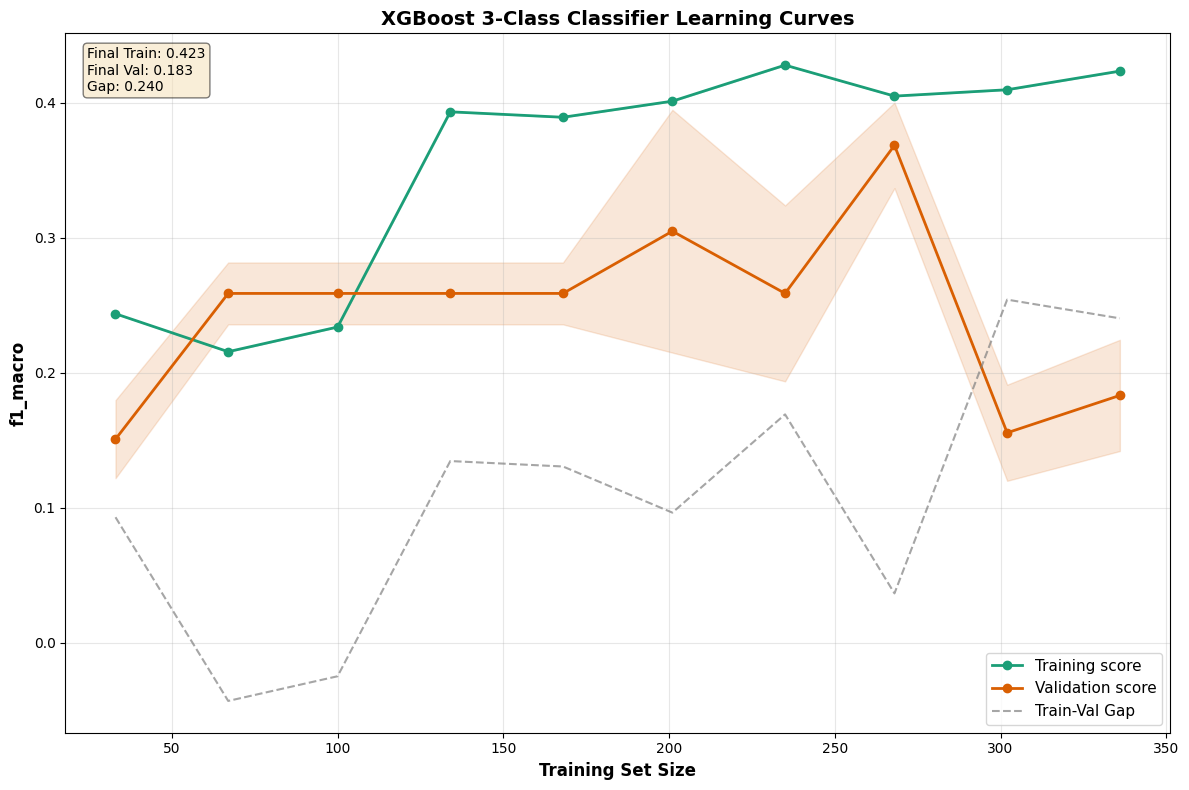

✓ Learning curves complete
  Final training score: 0.4233
  Final validation score: 0.1831
  Train-val gap: 0.2402
  ⚠ Warning: Large gap suggests overfitting



In [18]:
# Learning curves for best XGBoost model
if best_xgb_run is not None:
    from sklearn.base import clone
    
    # Use uncalibrated model for learning curve (calibrated model doesn't support set_params)
    xgb_for_learning_curve = clone(best_xgb_model_uncalibrated)
    xgb_for_learning_curve.set_params(**best_xgb_run['best_params'])
    
    # Remove early stopping for learning curves (no validation set available in learning_curve)
    xgb_for_learning_curve.set_params(early_stopping_rounds=None)
    
    # Create CV splitter
    lc_cv = model_utils.ExpandingWindowSplitter(
        n_splits=3,  # Use fewer splits for speed
        step_size=cfg.DEFAULT_EXPANDING_STEP,
        min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
    )
    
    # Prepare data with 3-class encoding
    X_train_xgb = best_dataset['train_df'][best_xgb_feature_columns].fillna(0)
    y_train_xgb = best_xgb_label_encoder.transform(
        best_dataset['train_df'][cfg.TARGET_COLUMN].astype(int)
    )
    
    visualization.plot_learning_curves(
        model=xgb_for_learning_curve,
        X_train=X_train_xgb,
        y_train=y_train_xgb,
        cv_splitter=lc_cv,
        scoring='f1_macro',
        model_name='XGBoost 3-Class Classifier'
    )

## 14. Stage 5: Model Evaluation

This cell tests the best XGBoost model on completely unseen test data (data the model has never encountered during training or validation). It calculates:
- **Overall accuracy**: Percentage of correct predictions
- **Macro F1-score**: Balanced performance across all three classes
- **Confusion matrix**: Shows which classes the model confuses with each other
- **Per-class recall**: How many true Long/Neutral/Short cases were correctly identified
- **Predictions per class**: How often the model predicts each class

This gives a realistic picture of how well the model will perform in the real world.

In [19]:
# Evaluate XGBoost on test set using helper function
if best_xgb_model is None:
    raise RuntimeError("XGBoost model not available. Please rerun Stage 4.")

xgb_test_results = model_utils.evaluate_xgb_test_set(
    model=best_xgb_model,
    test_df=best_dataset["test_df"],
    feature_columns=best_xgb_feature_columns,
    target_column=cfg.TARGET_COLUMN,
    label_encoder=best_xgb_label_encoder,
    model_name="XGBoost"
)

# Extract for downstream use
y_test = xgb_test_results["y_test"]
y_pred = xgb_test_results["y_pred"]
y_pred_proba = xgb_test_results["y_pred_proba"]
X_test_xgb = xgb_test_results["X_test"]


✓ XGBoost Test Evaluation (3-class)
  Argmax predictions → Acc=0.4594, Macro-F1=0.3315

CLASS-WISE METRICS: XGBoost Test Set

Confusion Matrix:
[[136   0 149]
 [ 51   0  71]
 [122   0 198]]

Per-Class Recall:
  Class -1: 0.477 (136/285)
  Class 0: 0.000 (0/122)
  Class 1: 0.619 (198/320)

Classification Report:
              precision    recall  f1-score   support

          -1       0.44      0.48      0.46       285
           0       0.00      0.00      0.00       122
           1       0.47      0.62      0.54       320

    accuracy                           0.46       727
   macro avg       0.30      0.37      0.33       727
weighted avg       0.38      0.46      0.42       727


Predictions per class:
  Class -1: 309 predictions (42.5%)
  Class 1: 418 predictions (57.5%)



## 15. Visualizations

These cells create diagnostic plots for the XGBoost model:
1. **Confusion matrix**: A color-coded grid showing actual vs predicted classes, revealing which types of errors the model makes
2. **ROC curves**: One curve per class showing the model's ability to distinguish between classes (line closer to top-left = better performance)
3. **Feature importance**: Bar chart ranking which features matter most to the model's decisions (e.g., are news signals more important than price history?)

These visualizations help you understand what the model learned and where it struggles.

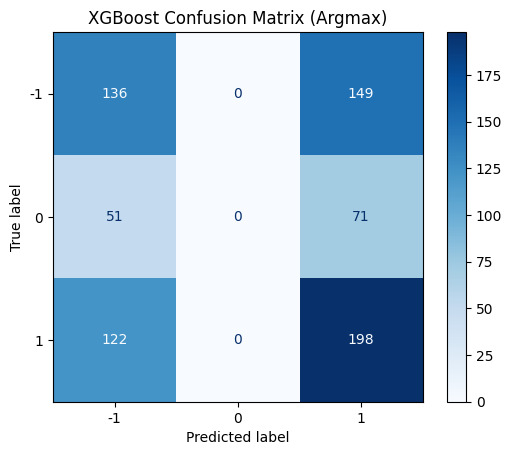

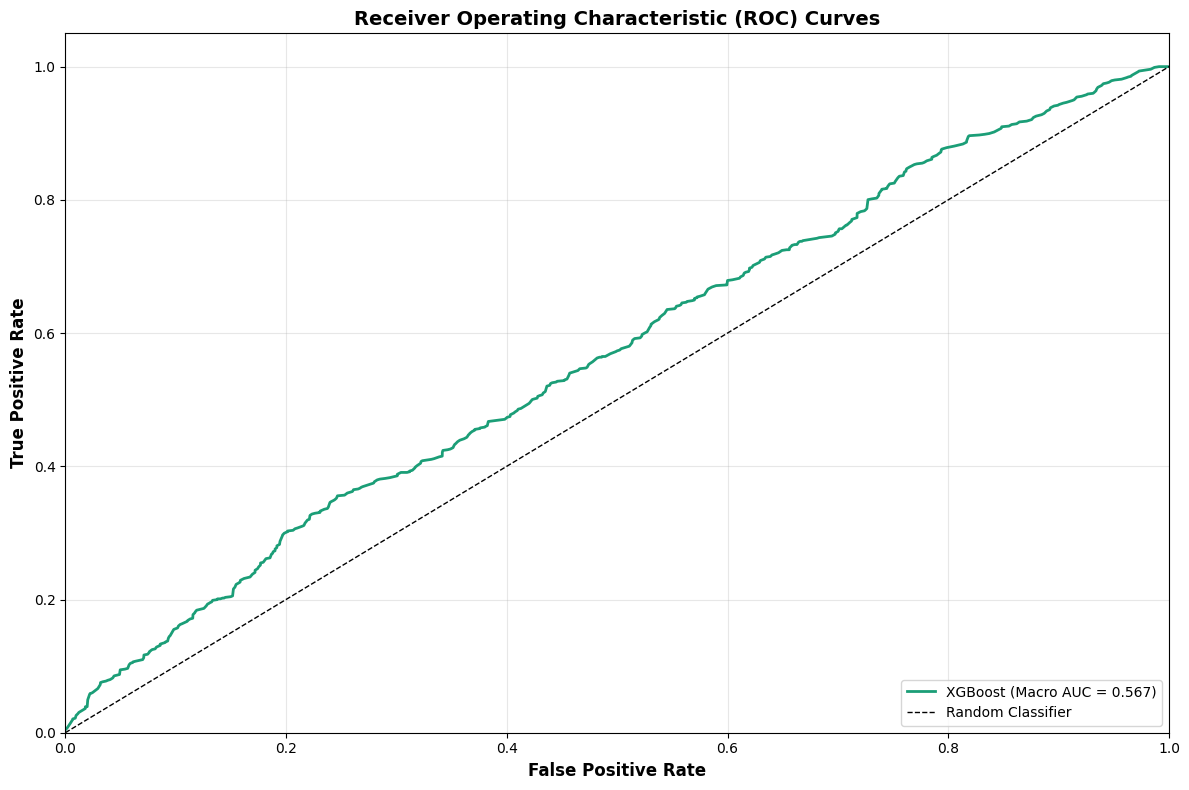

XGBoost Macro AUC: 0.567


In [20]:
# Confusion matrix (3-class)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_xgb_label_encoder.classes_
)
disp.plot(cmap='Blues', values_format='d')
plt.title('XGBoost Confusion Matrix (Argmax)')
plt.show()

# ROC Curves for XGBoost
xgb_auc_scores = visualization.plot_roc_curves(
    models_dict={"XGBoost": (best_xgb_model, X_test_xgb)},
    y_test=y_test,
    label_encoder=best_xgb_label_encoder
)
print(f"XGBoost Macro AUC: {xgb_auc_scores.get('XGBoost', 'N/A'):.3f}")

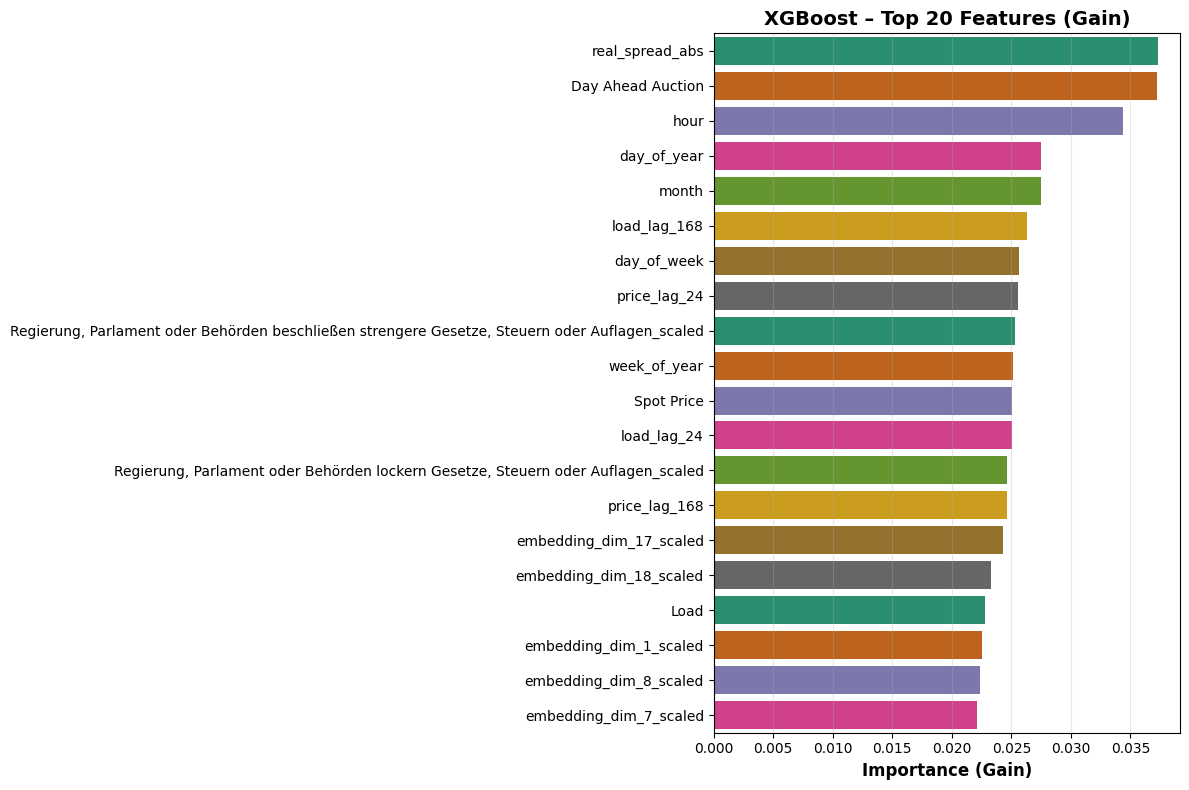

In [21]:
# Feature importance (use uncalibrated model since CalibratedClassifierCV doesn't expose feature_importances_)
importance_df = visualization.plot_feature_importance(
    model=best_xgb_model_uncalibrated,
    feature_names=best_xgb_feature_columns,
    model_name="XGBoost",
    top_n=20
)

## 16. Stage 6: LightGBM Signal Modelling

This stage trains two competing LightGBM models to test if the XGBoost predictions actually add value:

**Cell 34-35**: Prepares datasets by adding XGBoost predictions as new features. The "signal model" uses baseline price features + XGBoost predictions, while the "baseline model" uses only basic price/temporal features. Targets are encoded numerically for the model.

**Cell 36**: Trains both models using grid search to find the best hyperparameters. Each model is tested with 5-fold expanding-window cross-validation. Class imbalance is handled automatically with balanced class weights.

**Cell 37-38**: Evaluates both models on validation and test sets, showing detailed per-class metrics. By comparing the two models, we can see if adding XGBoost predictions (and thus news signals) improves performance beyond just using price history.

This two-stage approach (XGBoost → LightGBM) is like having two specialists review the same problem for better accuracy.

In [22]:
if best_xgb_model is None or best_dataset is None:
    raise RuntimeError("XGBoost model and dataset must be available before training LightGBM.")

# Prepare datasets for LightGBM using helper function
lgbm_prep = model_utils.prepare_lgbm_datasets(
    best_xgb_model=best_xgb_model,
    best_dataset=best_dataset,
    best_xgb_feature_columns=best_xgb_feature_columns,
    baseline_features=lgbm_baseline_features,
    target_column=cfg.TARGET_COLUMN,
    prediction_prefix="xgb"
)

signal_train_df = lgbm_prep["train_df"]
signal_val_df = lgbm_prep["val_df"]
signal_test_df = lgbm_prep["test_df"]
signal_feature_columns = lgbm_prep["signal_feature_columns"]
baseline_feature_columns = lgbm_prep["baseline_feature_columns"]
xgb_feature_names = lgbm_prep["xgb_feature_names"]

print("✓ Prepared LightGBM datasets with XGBoost features")
print(f"  Signal feature count: {len(signal_feature_columns)}")
print(f"  Baseline feature count: {len(baseline_feature_columns)}")
print(f"  XGBoost features added: {xgb_feature_names}")


✓ Prepared LightGBM datasets with XGBoost features
  Signal feature count: 7
  Baseline feature count: 3
  XGBoost features added: ['xgb_pred', 'xgb_prob_class0', 'xgb_prob_class1', 'xgb_prob_class2']


In [23]:
# Prepare and encode targets for LightGBM
target_prep = model_utils.prepare_lgbm_targets(
    train_df=signal_train_df,
    val_df=signal_val_df,
    test_df=signal_test_df,
    target_column=cfg.TARGET_COLUMN
)

y_train_signal = target_prep["y_train"]
y_val_signal = target_prep["y_val"]
y_test_signal = target_prep["y_test"]
label_encoder = target_prep["label_encoder"]

print("✓ Encoded LightGBM targets")
print(
    "  Classes:",
    dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
)


✓ Encoded LightGBM targets
  Classes: {np.int64(-1): np.int64(0), np.int64(0): np.int64(1), np.int64(1): np.int64(2)}


In [24]:
# Configure device for LightGBM
lgbm_device_config = device_utils.detect_compute_device(task='training', verbose=True)
print(f"LightGBM device: {lgbm_device_config.get('description')} • backend={lgbm_device_config.get('lgbm_device', lgbm_device_config.get('device'))} • jobs={lgbm_device_config.get('n_jobs')}")

# Train both signal and baseline LightGBM models (class imbalance handled via is_unbalance=True and class_weight='balanced')
with profiling.StageProfiler("Stage 6: LightGBM Signal & Baseline Models", device_config):
    lgbm_results = model_utils.train_lightgbm_pair(
        signal_train_df=signal_train_df,
        signal_val_df=signal_val_df,
        signal_test_df=signal_test_df,
        signal_feature_columns=signal_feature_columns,
        baseline_feature_columns=baseline_feature_columns,
        y_train=y_train_signal,
        y_val=y_val_signal,
        y_test=y_test_signal,
        label_encoder=label_encoder,
        param_grid=model_config.LIGHTGBM_PARAM_GRID,
        n_cv_splits=cfg.N_CV_SPLITS,
        cv_step_size=cfg.DEFAULT_EXPANDING_STEP,
        cv_min_train_size=cfg.DEFAULT_MIN_TRAIN_SIZE,
        device_config=lgbm_device_config,
        random_state=cfg.RANDOM_STATE
    )

# Extract trained models and artifacts
signal_best_lgbm = lgbm_results["signal_model"]
baseline_best_lgbm = lgbm_results["baseline_model"]
signal_column_rename_map = lgbm_results["signal_column_rename_map"]
baseline_column_rename_map = lgbm_results["baseline_column_rename_map"]
lgbm_artifacts = lgbm_results["evaluation"]
signal_test_pred = lgbm_artifacts["signal"]["test_pred"]
signal_test_proba = lgbm_artifacts["signal"]["test_proba"]
baseline_test_pred = lgbm_artifacts["baseline"]["test_pred"]
baseline_test_proba = lgbm_artifacts["baseline"]["test_proba"]
test_signal_X = lgbm_artifacts["signal"]["test_X"]
test_baseline_X = lgbm_artifacts["baseline"]["test_X"]

✓ MPS detected: Apple Silicon GPU
  Optimal batch size: 128
  XGBoost will fallback to CPU histogram (MPS unsupported)
LightGBM device: Apple MPS GPU • backend=cpu • jobs=6

[Stage ⏳] Stage 6: LightGBM Signal & Baseline Models — starting

TRAINING LIGHTGBM SIGNAL & BASELINE MODELS
Training SIGNAL model (baseline features + XGBoost predictions)...


✓ Signal model trained - Best CV macro-F1: 0.494
  Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}

Training BASELINE model (price/temporal features only)...
✓ Baseline model trained - Best CV macro-F1: 0.202
  Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}

Evaluating both models on validation and test sets...
✓ LightGBM validation performance
  Signal model  → Acc=0.448, Macro-F1=0.412
  Baseline model → Acc=0.388, Macro-F1=0.374

[Stage ✅] Stage 6: LightGBM Signal & Baseline Models — completed in 45.48s
  CPU usage: 96.4% • IO wait: 0.00%
  Disk Δ: +258.9 MB read, +20.7 MB written
  GPU metrics unavailable (install pynvml for CUDA visibility)


In [25]:
# Evaluate both models using helper function
lgbm_artifacts = model_utils.evaluate_lgbm_models(
    signal_model=signal_best_lgbm,
    baseline_model=baseline_best_lgbm,
    signal_feature_columns=signal_feature_columns,
    baseline_feature_columns=baseline_feature_columns,
    val_df=signal_val_df,
    test_df=signal_test_df,
    y_val=y_val_signal,
    y_test=y_test_signal,
    label_encoder=label_encoder,
    signal_column_rename_map=signal_column_rename_map,
    baseline_column_rename_map=baseline_column_rename_map,
)

# Extract artifacts for later use
signal_test_pred = lgbm_artifacts["signal"]["test_pred"]
signal_test_proba = lgbm_artifacts["signal"]["test_proba"]
baseline_test_pred = lgbm_artifacts["baseline"]["test_pred"]
baseline_test_proba = lgbm_artifacts["baseline"]["test_proba"]
test_signal_X = lgbm_artifacts["signal"]["test_X"]
test_baseline_X = lgbm_artifacts["baseline"]["test_X"]


✓ LightGBM validation performance
  Signal model  → Acc=0.448, Macro-F1=0.412
  Baseline model → Acc=0.388, Macro-F1=0.374


In [26]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Decode predictions for display
signal_test_decoded = label_encoder.inverse_transform(signal_test_pred)
baseline_test_decoded = label_encoder.inverse_transform(baseline_test_pred)
y_test_decoded = label_encoder.inverse_transform(y_test_signal)

# Compute test metrics
signal_test_accuracy = accuracy_score(y_test_signal, signal_test_pred)
signal_test_macro_f1 = f1_score(y_test_signal, signal_test_pred, average="macro", zero_division=0)
baseline_test_accuracy = accuracy_score(y_test_signal, baseline_test_pred)
baseline_test_macro_f1 = f1_score(y_test_signal, baseline_test_pred, average="macro", zero_division=0)

print("✓ LightGBM Test Performance")
print(f"  Signal model  → Acc={signal_test_accuracy:.3f}, Macro-F1={signal_test_macro_f1:.3f}")
print(f"  Baseline model → Acc={baseline_test_accuracy:.3f}, Macro-F1={baseline_test_macro_f1:.3f}\n")

# Display detailed class-wise metrics
model_utils.print_class_wise_metrics(y_true=y_test_signal, y_pred=signal_test_pred, label_encoder=label_encoder, dataset_name="LightGBM SIGNAL Model - Test Set")
model_utils.print_class_wise_metrics(y_true=y_test_signal, y_pred=baseline_test_pred, label_encoder=label_encoder, dataset_name="LightGBM BASELINE Model - Test Set")

✓ LightGBM Test Performance
  Signal model  → Acc=0.395, Macro-F1=0.363
  Baseline model → Acc=0.327, Macro-F1=0.328


CLASS-WISE METRICS: LightGBM SIGNAL Model - Test Set

Confusion Matrix:
[[137  75  73]
 [ 50  30  42]
 [140  60 120]]

Per-Class Recall:
  Class -1: 0.481 (137/285)
  Class 0: 0.246 (30/122)
  Class 1: 0.375 (120/320)

Classification Report:
              precision    recall  f1-score   support

          -1       0.42      0.48      0.45       285
           0       0.18      0.25      0.21       122
           1       0.51      0.38      0.43       320

    accuracy                           0.39       727
   macro avg       0.37      0.37      0.36       727
weighted avg       0.42      0.39      0.40       727


Predictions per class:
  Class -1: 327 predictions (45.0%)
  Class 0: 165 predictions (22.7%)
  Class 1: 235 predictions (32.3%)


CLASS-WISE METRICS: LightGBM BASELINE Model - Test Set

Confusion Matrix:
[[ 86 145  54]
 [ 28  57  37]
 [ 59 166  95]]

Per-C

## 17. LightGBM Model Diagnostics

These cells create visualizations comparing the Signal and Baseline LightGBM models:

**Cell 39**: Side-by-side confusion matrices showing prediction errors for both models

**Cell 40**: ROC curves measuring each model's ability to separate the three classes, with AUC scores (higher = better)

**Cell 41**: Statistical comparison using McNemar's test and bootstrap confidence intervals to determine if the signal model is genuinely better than baseline or if differences are just random chance

**Cell 42**: Feature importance plots showing which inputs drive each model's decisions, including SHAP analysis (advanced technique showing how features interact)

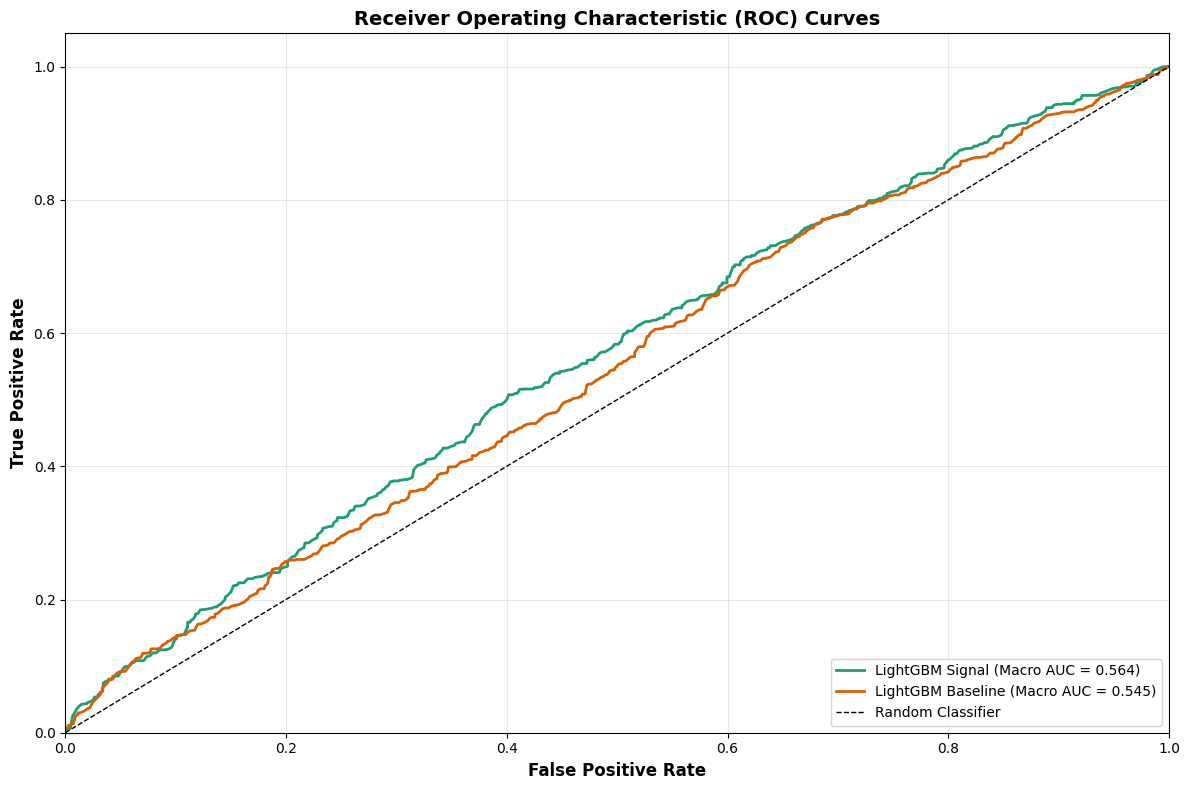

LightGBM Signal Macro AUC: 0.564
LightGBM Baseline Macro AUC: 0.545


In [27]:
# ROC Curves for LightGBM models
lgbm_auc_scores = visualization.plot_roc_curves(
    models_dict={
        "LightGBM Signal": (signal_best_lgbm, test_signal_X),
        "LightGBM Baseline": (baseline_best_lgbm, test_baseline_X),
    },
    y_test=y_test_signal,
    label_encoder=label_encoder
)
print(f"LightGBM Signal Macro AUC: {lgbm_auc_scores.get('LightGBM Signal', 'N/A'):.3f}")
print(f"LightGBM Baseline Macro AUC: {lgbm_auc_scores.get('LightGBM Baseline', 'N/A'):.3f}")

In [28]:
# Statistical comparison between signal and baseline models
statistical_results = evaluation.compare_models_statistically(
    y_test=y_test_decoded,
    signal_pred=signal_test_decoded,
    baseline_pred=baseline_test_decoded,
    signal_proba=signal_test_proba,
    baseline_proba=baseline_test_proba,
)
display(statistical_results)


STATISTICAL MODEL COMPARISON

Signal accuracy:   0.3948
Baseline accuracy: 0.3274

1. McNemar's Test (Paired Model Comparison)
----------------------------------------------------------------------
Both models correct:       114
Only signal correct:       173
Only baseline correct:     124
Both models wrong:         316

Signal model correct:      287
Baseline model correct:    238

McNemar's χ² statistic:    7.7576
p-value:                   0.0053

✓ Signal model is SIGNIFICANTLY better (p < 0.01) **


2. Bootstrap 95% Confidence Intervals for Accuracy
----------------------------------------------------------------------
Signal model:   0.3949 [0.3590, 0.4305]
Baseline model: 0.3283 [0.2930, 0.3632]
Difference:     +0.0666

○ Confidence intervals overlap - weaker evidence of difference




{'mcnemar_statistic': np.float64(7.757575757575758),
 'mcnemar_p_value': np.float64(0.0053487705204819935),
 'signal_acc_mean': np.float64(0.3949009628610729),
 'signal_acc_ci': (np.float64(0.35900962861072905),
  np.float64(0.4305364511691884)),
 'baseline_acc_mean': np.float64(0.32833562585969733),
 'baseline_acc_ci': (np.float64(0.29298486932599727),
  np.float64(0.36317056396148556))}

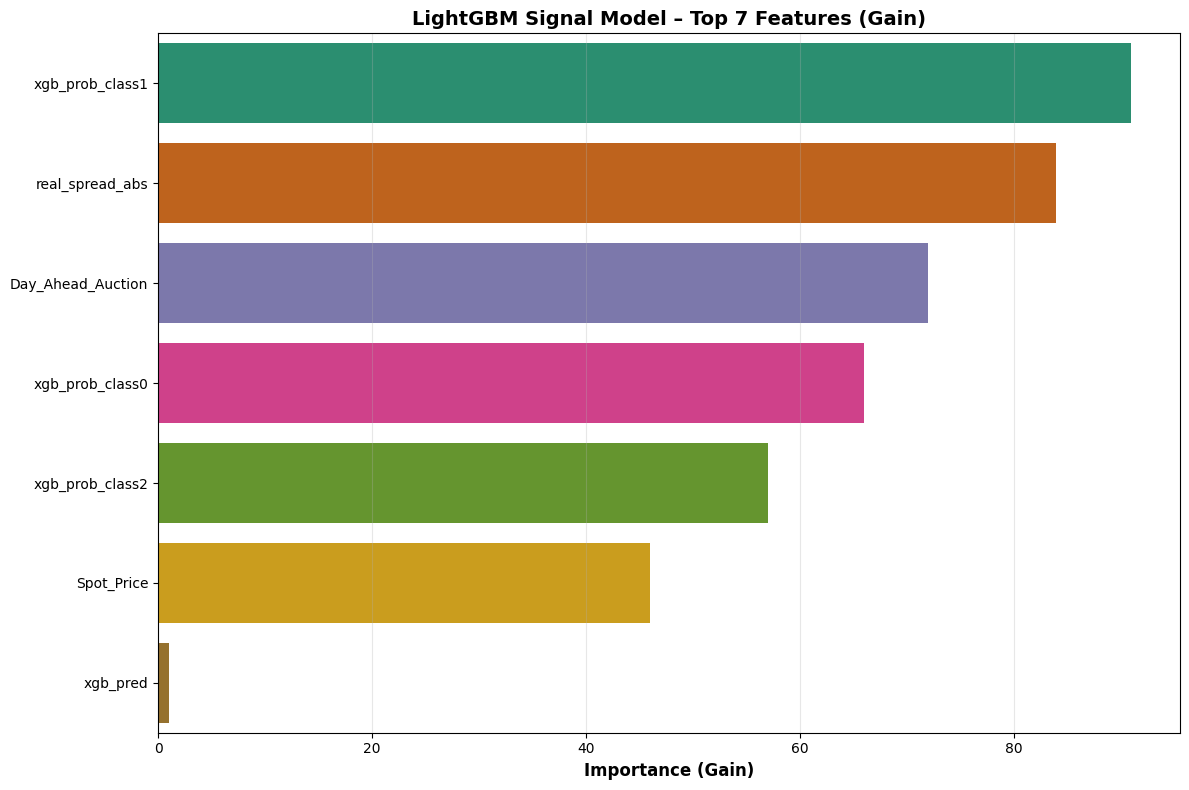

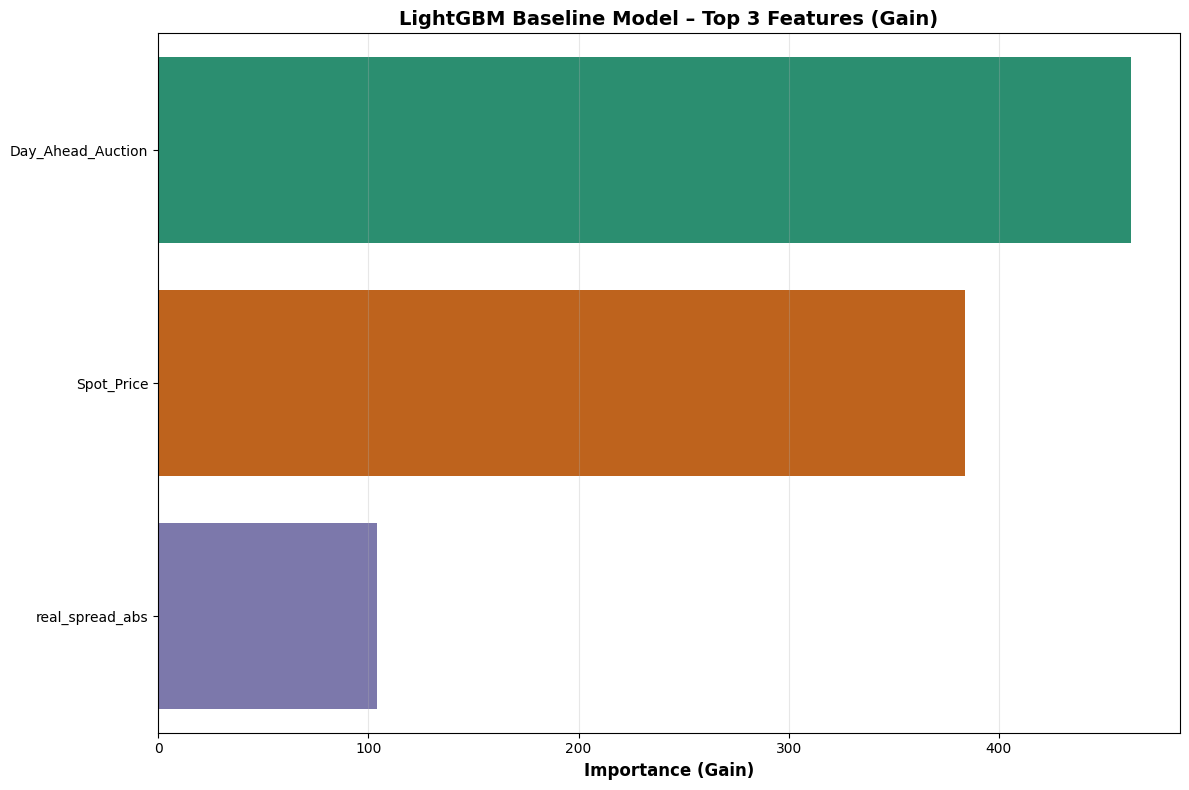

SHAP not installed. Install with: pip install shap
SHAP not installed. Install with: pip install shap


In [29]:
# Feature importance for LightGBM models
signal_feature_columns_sanitized = list(signal_column_rename_map.values())
baseline_feature_columns_sanitized = list(baseline_column_rename_map.values())

visualization.plot_feature_importance(
    model=signal_best_lgbm,
    feature_names=signal_feature_columns_sanitized,
    model_name="LightGBM Signal Model",
    top_n=20,
)
visualization.plot_feature_importance(
    model=baseline_best_lgbm,
    feature_names=baseline_feature_columns_sanitized,
    model_name="LightGBM Baseline Model",
    top_n=20,
)

# SHAP feature importance
visualization.plot_feature_importance_shap(
    model=signal_best_lgbm,
    X_test=test_signal_X,
    feature_names=signal_feature_columns_sanitized,
    model_name="LightGBM Signal Model",
)
visualization.plot_feature_importance_shap(
    model=baseline_best_lgbm,
    X_test=test_baseline_X,
    feature_names=baseline_feature_columns_sanitized,
    model_name="LightGBM Baseline Model",
)

## 18. Portfolio Backtest Analysis

These cells simulate realistic trading with a portfolio starting at €100,000:

**Cell 49**: Runs portfolio-based backtests for both signal and baseline models. Each trade allocates 10% of current portfolio value, with realistic transaction costs (€0.50/MWh + 0.05%). Shows equity curves and summary metrics including total return, Sharpe ratio, max drawdown, and win rate.

**Cell 50**: Equity curve visualization showing portfolio value over time for both strategies, with initial capital reference line.

**Cell 51**: Drawdown analysis showing portfolio drawdowns from peak value, revealing periods of underperformance.

This answers the critical question: "Would using this model to trade actually make money with realistic costs and position sizing?"

In [30]:
# Portfolio Backtest Configuration
INITIAL_CAPITAL = 100_000  # EUR
POSITION_PCT = 0.10        # 10% of portfolio per trade
FIXED_COST = 0.50          # EUR/MWh
PCT_COST = 0.0005          # 0.05%

# Run backtests for each strategy
signal_backtest = evaluation.run_portfolio_backtest(
    test_df=signal_test_df,
    predictions=signal_test_pred,
    label_encoder=label_encoder,
    initial_capital=INITIAL_CAPITAL,
    position_pct=POSITION_PCT,
    fixed_cost_per_mwh=FIXED_COST,
    pct_cost=PCT_COST,
)

baseline_backtest = evaluation.run_portfolio_backtest(
    test_df=signal_test_df,
    predictions=baseline_test_pred,
    label_encoder=label_encoder,
    initial_capital=INITIAL_CAPITAL,
    position_pct=POSITION_PCT,
    fixed_cost_per_mwh=FIXED_COST,
    pct_cost=PCT_COST,
)

# Display summary
print(f"Portfolio Backtest Configuration:")
print(f"  Initial Capital: €{INITIAL_CAPITAL:,.0f}")
print(f"  Position Size: {POSITION_PCT*100:.0f}% per trade")
print(f"  Transaction Costs: €{FIXED_COST}/MWh + {PCT_COST*100:.2f}%")
print()

summary = pd.DataFrame({
    "Signal Model": signal_backtest["metrics"],
    "Baseline Model": baseline_backtest["metrics"],
}).T
display(summary)

Portfolio Backtest Configuration:
  Initial Capital: €100,000
  Position Size: 10% per trade
  Transaction Costs: €0.5/MWh + 0.05%



,Final Value (EUR),Total Return (%),Annualized Return (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%),Win Rate (%),Total Trades,Total Costs (EUR)
Signal Model,284870.706859,184.870707,3.008054e+07,1.345462e+05,1.654019e+05,-33.918077,58.007117,562.0,36339.448837
Baseline Model,660622.300439,560.622300,7.586504e+11,5.143790e+09,1.318314e+10,-3.871119,76.044568,359.0,26454.766829


Figure saved: outputs/figures/equity_curve.png


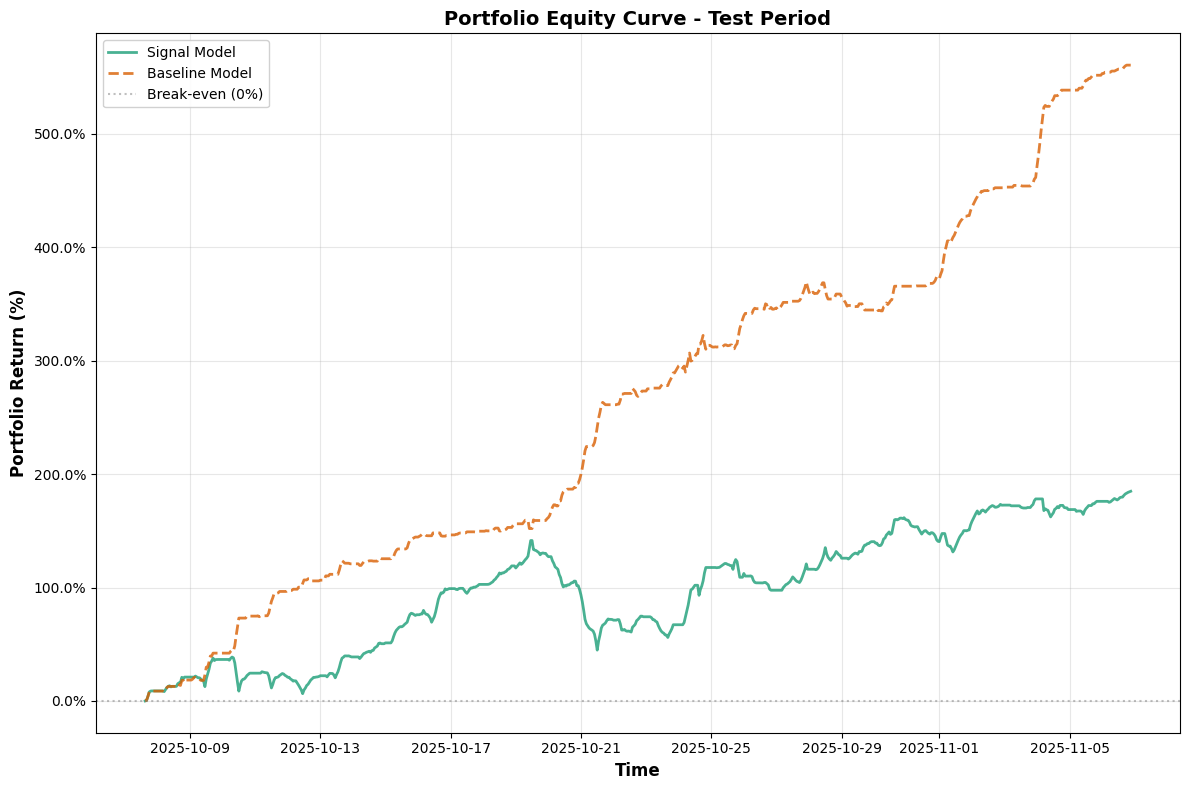

In [31]:
# Plot equity curves (showing % returns)
visualization.plot_equity_curve(
    equity_curves={
        "Signal Model": signal_backtest["equity_curve"],
        "Baseline Model": baseline_backtest["equity_curve"],
    },
    initial_capital=INITIAL_CAPITAL,
    title="Portfolio Equity Curve - Test Period",
    save_path="equity_curve",
    show_pct_return=True,  # Display percentage returns instead of absolute EUR
)

Figure saved: outputs/figures/portfolio_drawdown.png


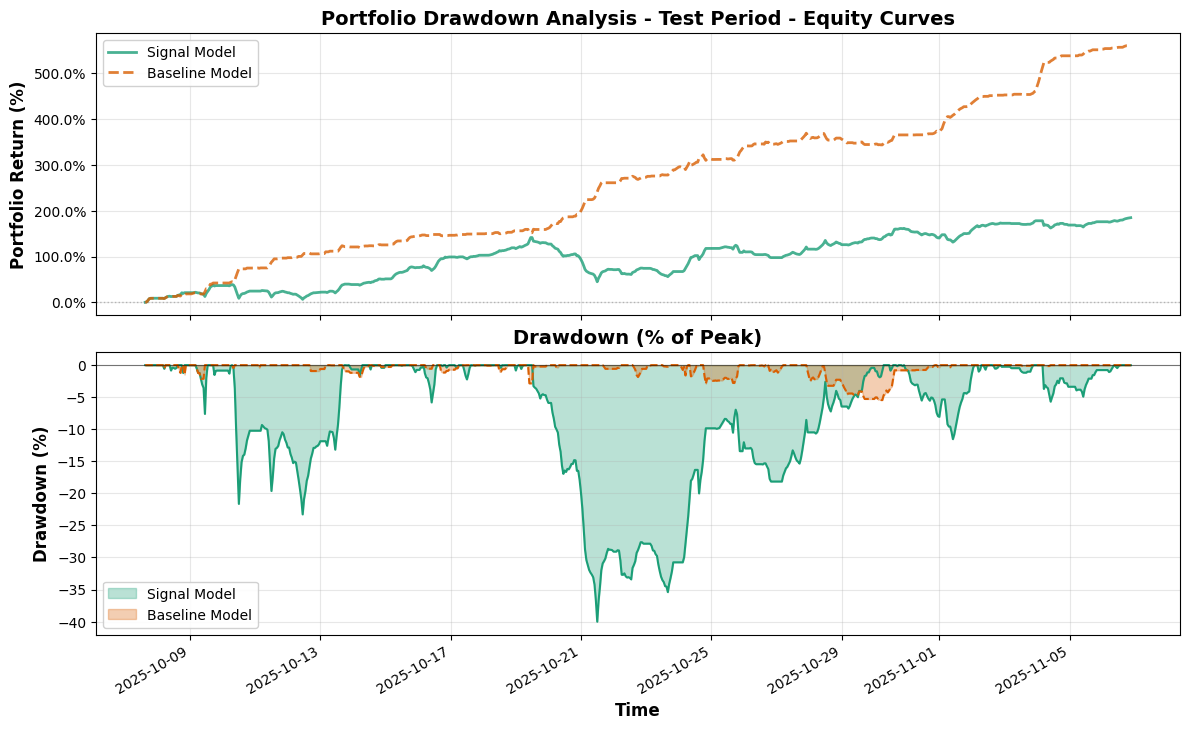

In [32]:
# Plot drawdown analysis (showing % returns)
visualization.plot_portfolio_drawdown(
    equity_curves={
        "Signal Model": signal_backtest["equity_curve"],
        "Baseline Model": baseline_backtest["equity_curve"],
    },
    initial_capital=INITIAL_CAPITAL,
    title="Portfolio Drawdown Analysis - Test Period",
    save_path="portfolio_drawdown",
    show_pct_return=True,  # Display percentage returns instead of absolute EUR
)

In [33]:
# Analyze equity tail to investigate large drops
# Check if there's a significant drop in the final periods
final_20_periods_start = signal_backtest["equity_curve"].iloc[-20]
final_value = signal_backtest["equity_curve"].iloc[-1]
drop_pct = ((final_value - final_20_periods_start) / final_20_periods_start) * 100

if abs(drop_pct) > 5:  # If drop > 5% in last 20 periods
    print(f"⚠ Significant change detected in final 20 periods: {drop_pct:+.2f}%")
    print("Analyzing tail period...\n")
    evaluation.analyze_equity_tail(
        signal_backtest,
        n_periods=20,
        initial_capital=INITIAL_CAPITAL,
    )
else:
    print(f"✓ No significant drop detected in final periods ({drop_pct:+.2f}%)")


✓ No significant drop detected in final periods (+3.22%)
